In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Cargar archivo
df = pd.read_csv("DATASET_Viol_Cont_Muj_Ene 2018 a Mar 2026.csv", encoding="utf-8-sig")

# Limpiar nombres de columnas
df.columns = df.columns.str.replace("\ufeff", "", regex=False).str.strip()

df.head()

,MODALIDAD,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,AÑO,MES,DPTO_HECHO,CANTIDAD
0,VIOLENCIA ECONOMICA O PATRIMONIAL,HUANCAYO,HUANCAYO,120101,2020,3,JUNIN,5
1,VIOLENCIA PSICOLOGICA,ICA,OCUCAJE,110104,2020,5,ICA,7
2,VIOLENCIA PSICOLOGICA,ILO,ILO,180301,2020,11,MOQUEGUA,83
3,VIOLENCIA FISICA,LA CONVENCION,MARANURA,80904,2023,12,CUSCO,1
4,VIOLENCIA PSICOLOGICA,CUTERVO,CUTERVO,60601,2018,2,CAJAMARCA,7


Tipo de datos

In [2]:
print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

display(df.head())
display(df.tail())

Filas y columnas: (194425, 8)

Columnas:
['MODALIDAD', 'PROV_HECHO', 'DIST_HECHO', 'UBIGEO_HECHO', 'AÑO', 'MES', 'DPTO_HECHO', 'CANTIDAD']

Tipos de datos:
MODALIDAD       object
PROV_HECHO      object
DIST_HECHO      object
UBIGEO_HECHO     int64
AÑO              int64
MES              int64
DPTO_HECHO      object
CANTIDAD         int64
dtype: object


,MODALIDAD,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,AÑO,MES,DPTO_HECHO,CANTIDAD
0,VIOLENCIA ECONOMICA O PATRIMONIAL,HUANCAYO,HUANCAYO,120101,2020,3,JUNIN,5
1,VIOLENCIA PSICOLOGICA,ICA,OCUCAJE,110104,2020,5,ICA,7
2,VIOLENCIA PSICOLOGICA,ILO,ILO,180301,2020,11,MOQUEGUA,83
3,VIOLENCIA FISICA,LA CONVENCION,MARANURA,80904,2023,12,CUSCO,1
4,VIOLENCIA PSICOLOGICA,CUTERVO,CUTERVO,60601,2018,2,CAJAMARCA,7


,MODALIDAD,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,AÑO,MES,DPTO_HECHO,CANTIDAD
194420,VIOLENCIA FISICA,AREQUIPA,YURA,40128,2020,6,AREQUIPA,3
194421,VIOLENCIA PSICOLOGICA,TRUJILLO,TRUJILLO,130101,2018,9,LA LIBERTAD,111
194422,VIOLENCIA FISICA,UTCUBAMBA,JAMALCA,10705,2021,8,AMAZONAS,4
194423,VIOLENCIA PSICOLOGICA,MARISCAL CACERES,CAMPANILLA,220602,2025,8,SAN MARTIN,1
194424,VIOLENCIA FISICA,CALLAO,LA PUNTA,70105,2025,3,PROV. CONST. DEL CALLAO,1


In [3]:
# Faltantes
faltantes = df.isna().sum().reset_index()
faltantes.columns = ["Variable", "Faltantes"]
faltantes["% Faltantes"] = (faltantes["Faltantes"] / len(df)) * 100
display(faltantes.sort_values("% Faltantes", ascending=False))

# Duplicados exactos
print("Duplicados exactos:", df.duplicated().sum())

# Valores inválidos
print("Cantidad <= 0:", (df["CANTIDAD"] <= 0).sum())
print("Meses fuera de rango:", ((df["MES"] < 1) | (df["MES"] > 12)).sum())

print("Años disponibles:", sorted(df["AÑO"].unique()))
print("Meses disponibles:", sorted(df["MES"].unique()))

,Variable,Faltantes,% Faltantes
0,MODALIDAD,0,0.0
1,PROV_HECHO,0,0.0
2,DIST_HECHO,0,0.0
3,UBIGEO_HECHO,0,0.0
4,AÑO,0,0.0
5,MES,0,0.0
6,DPTO_HECHO,0,0.0
7,CANTIDAD,0,0.0


Duplicados exactos: 0
Cantidad <= 0: 0
Meses fuera de rango: 0
Años disponibles: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Meses disponibles: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]


VARIABLE UBIGEO

In [4]:
df["UBIGEO_HECHO"] = df["UBIGEO_HECHO"].astype(str).str.zfill(6)

df["COD_DPTO"] = df["UBIGEO_HECHO"].str[:2]
df["COD_PROV"] = df["UBIGEO_HECHO"].str[:4]
df["COD_DIST"] = df["UBIGEO_HECHO"].str[:6]

df["FECHA"] = pd.to_datetime(
    df["AÑO"].astype(str) + "-" + df["MES"].astype(str).str.zfill(2) + "-01"
)

df.head()

,MODALIDAD,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,AÑO,MES,DPTO_HECHO,CANTIDAD,COD_DPTO,COD_PROV,COD_DIST,FECHA
0,VIOLENCIA ECONOMICA O PATRIMONIAL,HUANCAYO,HUANCAYO,120101,2020,3,JUNIN,5,12,1201,120101,2020-03-01
1,VIOLENCIA PSICOLOGICA,ICA,OCUCAJE,110104,2020,5,ICA,7,11,1101,110104,2020-05-01
2,VIOLENCIA PSICOLOGICA,ILO,ILO,180301,2020,11,MOQUEGUA,83,18,1803,180301,2020-11-01
3,VIOLENCIA FISICA,LA CONVENCION,MARANURA,080904,2023,12,CUSCO,1,08,0809,080904,2023-12-01
4,VIOLENCIA PSICOLOGICA,CUTERVO,CUTERVO,060601,2018,2,CAJAMARCA,7,06,0606,060601,2018-02-01


In [5]:
display(df.describe(include="all"))

print("Total de denuncias:", df["CANTIDAD"].sum())
print("Mínimo:", df["CANTIDAD"].min())
print("Máximo:", df["CANTIDAD"].max())
print("Promedio:", df["CANTIDAD"].mean())
print("Mediana:", df["CANTIDAD"].median())

,MODALIDAD,PROV_HECHO,DIST_HECHO,UBIGEO_HECHO,AÑO,MES,DPTO_HECHO,CANTIDAD,COD_DPTO,COD_PROV,COD_DIST,FECHA
count,194425,194425,194425,194425,194425.000000,194425.000000,194425,194425.000000,194425,194425,194425,194425
unique,8,195,1654,1804,NaN,NaN,26,NaN,25,196,1804,NaN
top,VIOLENCIA PSICOLOGICA,LIMA,BELLAVISTA,150101,NaN,NaN,LIMA METROPOLITANA,NaN,15,1501,150101,NaN
freq,80278,15550,1022,488,NaN,NaN,15550,NaN,25874,15550,488,NaN
mean,NaN,NaN,NaN,NaN,2021.705732,6.441960,NaN,13.425115,NaN,NaN,NaN,2022-02-27 08:19:55.698084096
min,NaN,NaN,NaN,NaN,2018.000000,1.000000,NaN,1.000000,NaN,NaN,NaN,2018-01-01 00:00:00
25%,NaN,NaN,NaN,NaN,2020.000000,3.000000,NaN,1.000000,NaN,NaN,NaN,2020-02-01 00:00:00
50%,NaN,NaN,NaN,NaN,2022.000000,6.000000,NaN,3.000000,NaN,NaN,NaN,2022-03-01 00:00:00
75%,NaN,NaN,NaN,NaN,2024.000000,10.000000,NaN,10.000000,NaN,NaN,NaN,2024-03-01 00:00:00
max,NaN,NaN,NaN,NaN,2026.000000,12.000000,NaN,862.000000,NaN,NaN,NaN,2026-03-01 00:00:00


Total de denuncias: 2610178
Mínimo: 1
Máximo: 862
Promedio: 13.425115082936864
Mediana: 3.0


DISTRIBUCIÓN DE LA VARIABLE DE CANTIDAD

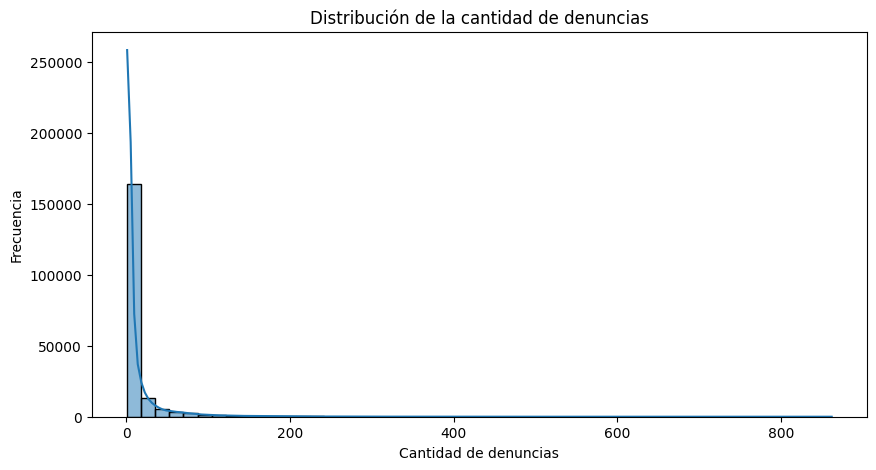

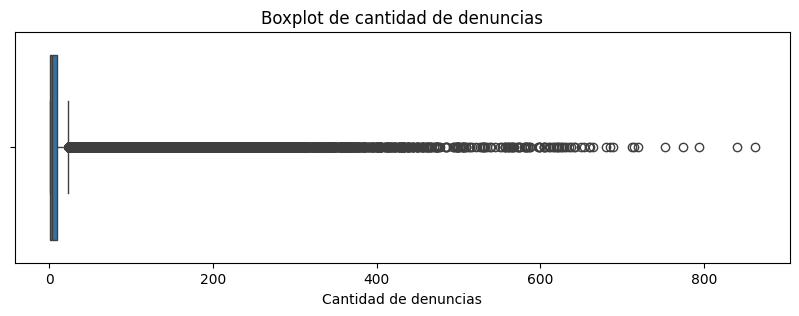

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df["CANTIDAD"], bins=50, kde=True)
plt.title("Distribución de la cantidad de denuncias")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(10,3))
sns.boxplot(x=df["CANTIDAD"])
plt.title("Boxplot de cantidad de denuncias")
plt.xlabel("Cantidad de denuncias")
plt.show()

DENUNCIAS POR MODALIDAD

,MODALIDAD,CANTIDAD
6,VIOLENCIA PSICOLOGICA,1457942
4,VIOLENCIA FISICA,843543
5,VIOLENCIA FISICA Y PSICOLOGICA,214733
3,VIOLENCIA ECONOMICA O PATRIMONIAL,75301
7,VIOLENCIA SEXUAL,15813
0,AMENAZA GRAVE,1541
2,MALTRATO SIN LESION,894
1,COACCION GRAVE,411


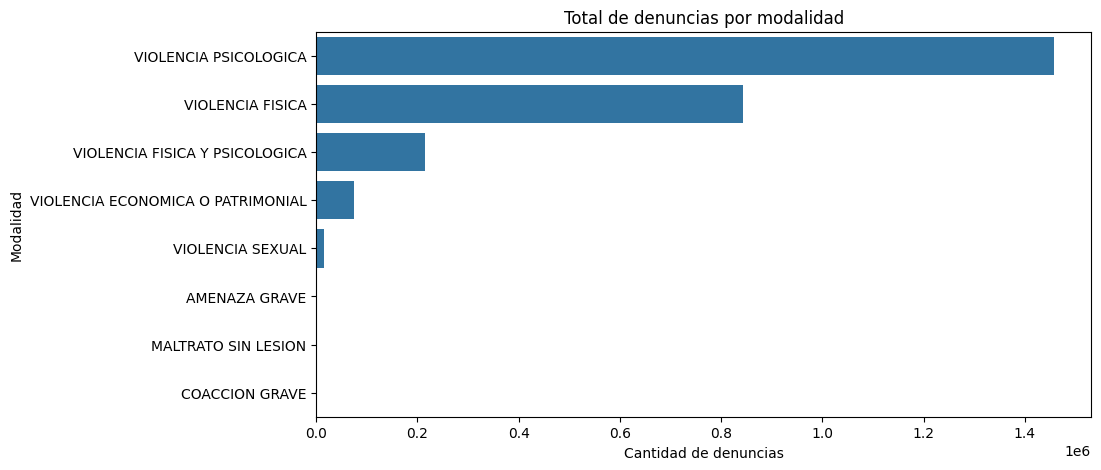

In [7]:
modalidad = (
    df.groupby("MODALIDAD", as_index=False)["CANTIDAD"]
    .sum()
    .sort_values("CANTIDAD", ascending=False)
)

display(modalidad)

plt.figure(figsize=(10,5))
sns.barplot(data=modalidad, y="MODALIDAD", x="CANTIDAD")
plt.title("Total de denuncias por modalidad")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Modalidad")
plt.show()

EVOLUCIÓN ANUAL POR MODALIDAD

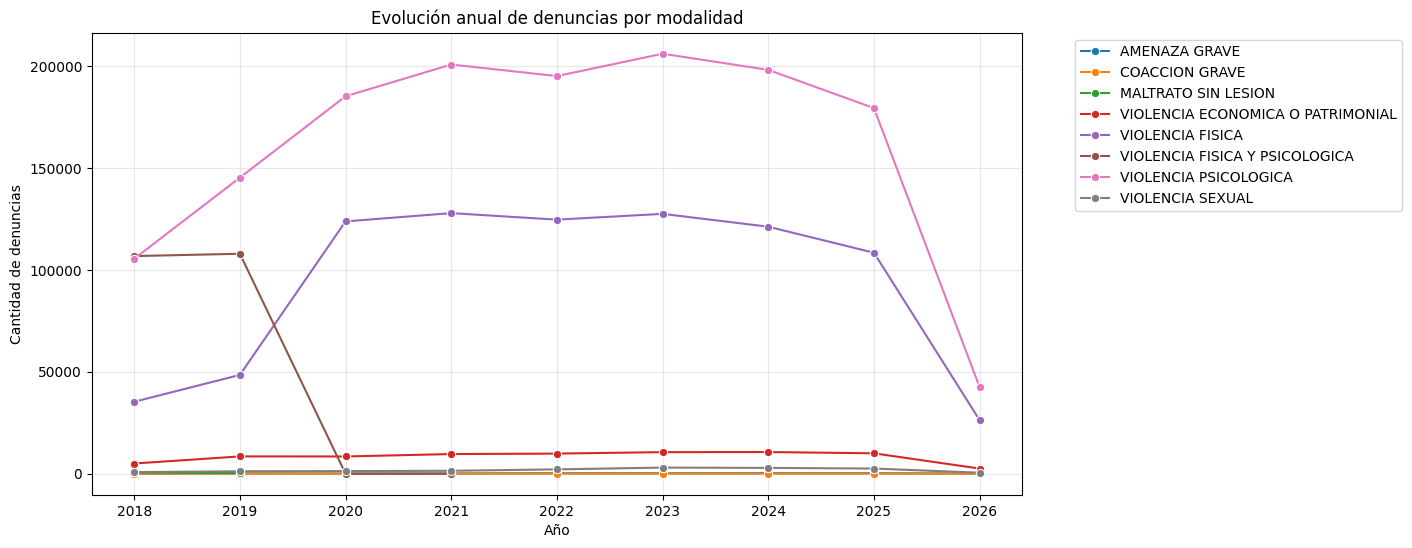

In [8]:
anio_modalidad = df.groupby(["AÑO", "MODALIDAD"], as_index=False)["CANTIDAD"].sum()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=anio_modalidad,
    x="AÑO",
    y="CANTIDAD",
    hue="MODALIDAD",
    marker="o"
)
plt.title("Evolución anual de denuncias por modalidad")
plt.xlabel("Año")
plt.ylabel("Cantidad de denuncias")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

RANKING POR DEPARTAMENTO

,DPTO_HECHO,CANTIDAD
13,LIMA METROPOLITANA,822367
3,AREQUIPA,185817
18,PIURA,136894
6,CUSCO,127652
10,JUNIN,125396
12,LAMBAYEQUE,120524
11,LA LIBERTAD,116448
1,ANCASH,104451
19,PROV. CONST. DEL CALLAO,96657
9,ICA,95218


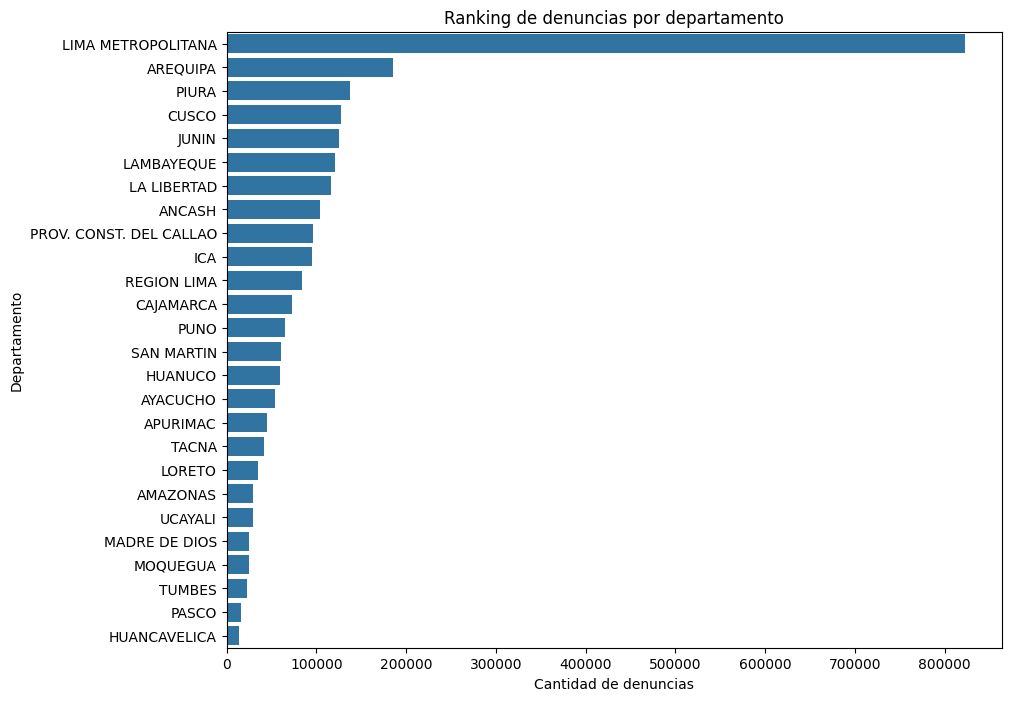

In [9]:
dpto = (
    df.groupby("DPTO_HECHO", as_index=False)["CANTIDAD"]
    .sum()
    .sort_values("CANTIDAD", ascending=False)
)

display(dpto)

plt.figure(figsize=(10,8))
sns.barplot(data=dpto, y="DPTO_HECHO", x="CANTIDAD")
plt.title("Ranking de denuncias por departamento")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Departamento")
plt.show()

MODALIDAD POR DEPARTAMENTO

MODALIDAD,AMENAZA GRAVE,COACCION GRAVE,MALTRATO SIN LESION,VIOLENCIA ECONOMICA O PATRIMONIAL,VIOLENCIA FISICA,VIOLENCIA FISICA Y PSICOLOGICA,VIOLENCIA PSICOLOGICA,VIOLENCIA SEXUAL
DPTO_HECHO,,,,,,,,
AMAZONAS,22,9,32,836,9073,2767,16540,107
ANCASH,14,8,42,3684,32305,8554,59475,369
APURIMAC,6,1,20,387,19039,5697,20117,106
AREQUIPA,40,13,117,3214,54418,17605,109146,1264
AYACUCHO,8,2,51,805,18179,5309,28899,95
CAJAMARCA,32,20,16,933,26149,6577,38385,193
CUSCO,11,8,78,985,45206,13860,64727,2777
HUANCAVELICA,6,1,2,162,5456,951,7506,37
HUANUCO,8,3,4,542,19654,5411,33817,78


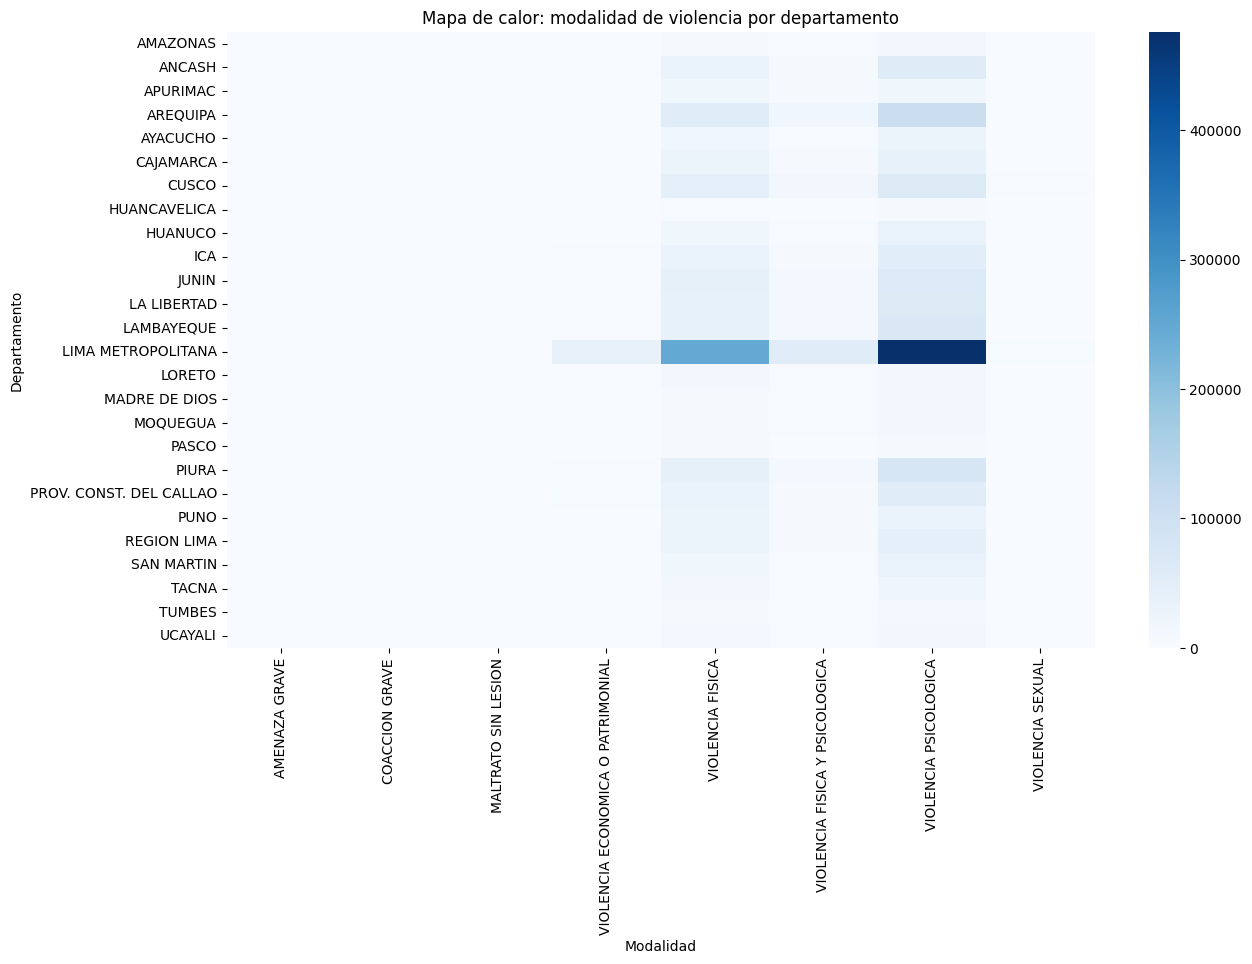

In [10]:
tabla_dpto_modalidad = df.pivot_table(
    index="DPTO_HECHO",
    columns="MODALIDAD",
    values="CANTIDAD",
    aggfunc="sum",
    fill_value=0
)

display(tabla_dpto_modalidad)

plt.figure(figsize=(14,8))
sns.heatmap(tabla_dpto_modalidad, cmap="Blues")
plt.title("Mapa de calor: modalidad de violencia por departamento")
plt.xlabel("Modalidad")
plt.ylabel("Departamento")
plt.show()

Top 20 distritos con más denuncias

,UBIGEO_HECHO,DPTO_HECHO,PROV_HECHO,DIST_HECHO,CANTIDAD
1267,150132,LIMA METROPOLITANA,LIMA,SAN JUAN DE LURIGANCHO,93262
1236,150101,LIMA METROPOLITANA,LIMA,LIMA,60792
1238,150103,LIMA METROPOLITANA,LIMA,ATE,59213
1245,150110,LIMA METROPOLITANA,LIMA,COMAS,58523
668,070101,PROV. CONST. DEL CALLAO,CALLAO,CALLAO,57759
1270,150135,LIMA METROPOLITANA,LIMA,SAN MARTIN DE PORRES,44338
1278,150143,LIMA METROPOLITANA,LIMA,VILLA MARIA DEL TRIUNFO,41218
1198,140101,LAMBAYEQUE,CHICLAYO,CHICLAYO,38635
1252,150117,LIMA METROPOLITANA,LIMA,LOS OLIVOS,38550
1241,150106,LIMA METROPOLITANA,LIMA,CARABAYLLO,37769


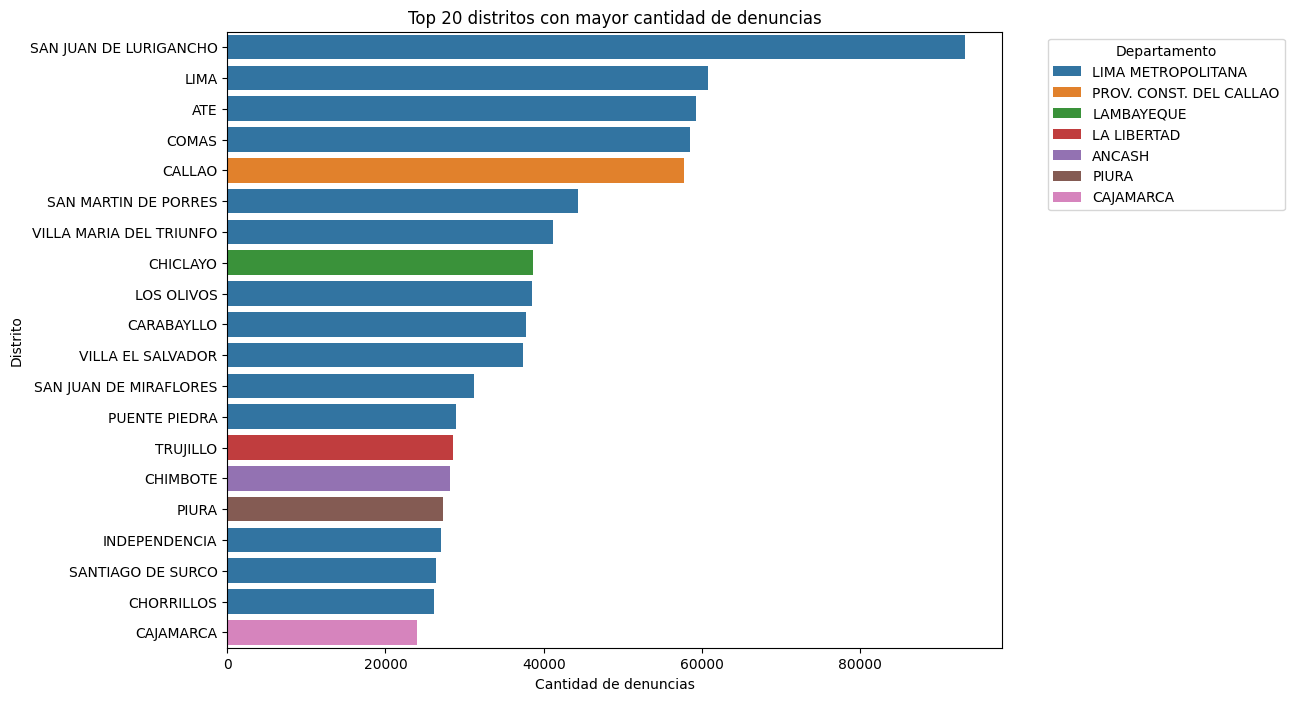

In [11]:
distritos = (
    df.groupby(["UBIGEO_HECHO", "DPTO_HECHO", "PROV_HECHO", "DIST_HECHO"], as_index=False)["CANTIDAD"]
    .sum()
    .sort_values("CANTIDAD", ascending=False)
)

top20 = distritos.head(20)
display(top20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20, y="DIST_HECHO", x="CANTIDAD", hue="DPTO_HECHO", dodge=False)
plt.title("Top 20 distritos con mayor cantidad de denuncias")
plt.xlabel("Cantidad de denuncias")
plt.ylabel("Distrito")
plt.legend(title="Departamento", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()